<a href="https://colab.research.google.com/github/sk6952217-pixel/Day19_Shivam-Kumar_Controlled-Hyperparameter-Parameter-Experiments/blob/main/Day19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project on Underwater Image Enhancement

## DAY 1-7

In [1]:
import zipfile # Import the zipfile module

zip_path = "/content/Underwater-Image-Data-set-main.zip" # Define the path to the ZIP file
extract_path = "/content/underwater_dataset" # Define the directory where the files will be extracted

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

In [2]:
# Install 7zip, a command-line archiving tool
!apt-get -qq install p7zip-full

# Define the path to the dataset folder which contains .7z archives
dataset = "/content/underwater_dataset/Underwater-Image-Data-set-main"

output = "/content/images"

!mkdir -p /content/images
!7z x "$dataset/*.7z" -o"$output" -y


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/underwater_dataset/Underwater-Image-Data-set-main/                                                                     8 files, 151077006 bytes (145 MiB)
  0%    
Extracting archive: /content/underwater_dataset/Underwater-Image-Data-set-main/epoch_00100.7z
--
Path = /content/underwater_dataset/Underwater-Image-Data-set-main/epoch_00100.7z
Type = 7z
Physical Size = 31290555
Headers Size = 8080
Method = LZMA:23
Solid = +
Blocks = 1

  0%      1%      3% 57 - epoch_0100/img 118_gen.png                                    

In [3]:
#Count images
import os

dataset = "/content/images" # Corrected dataset path

#intialize to 0
input_count = 0
target_count = 0
gen_count = 0

#look inside the folder and subfolder
for root, dirs, files in os.walk(dataset):

    for file in files: #check each file one by one

        if "_input.png" in file:  #if file name is "_input.png" input_count increase with 1
            input_count = input_count + 1

        elif "_target.png" in file:  #if file name is "_target.png" target_count increase with 1
            target_count = target_count + 1

        elif "_gen.png" in file:
            gen_count = gen_count + 1

#shows the final count
print("Input images:", input_count)
print("Target images:", target_count)
print("Generated images:", gen_count)
#counts the total
print("Total:", input_count + target_count + gen_count)

Input images: 1078
Target images: 1078
Generated images: 1078
Total: 3234


In [4]:
#check dimension
import os
from PIL import Image
from collections import Counter

dataset = "/content/images"

for folder in sorted(os.listdir(dataset)): #loop through each subfolder
    path = os.path.join(dataset, folder)

    if os.path.isdir(path): #Check if the item is actually a directory
        dimensions = []
        for file in os.listdir(path):

            if file.endswith(".png"):# only process png images
                try:
                    img = Image.open(os.path.join(path, file))#open the image and record its width and heigh
                    dimensions.append(img.size)
                except:
                    pass #skip file that fail to open
        count = Counter(dimensions)
        print("\n", folder)
        print("Total images:", len(dimensions))
        print("Dimensions:", dict(count))


 epoch_0096
Total images: 471
Dimensions: {(256, 256): 471}

 epoch_0100
Total images: 465
Dimensions: {(256, 256): 465}

 epoch_0110
Total images: 460
Dimensions: {(256, 256): 460}

 epoch_0115
Total images: 459
Dimensions: {(256, 256): 459}

 epoch_0120
Total images: 459
Dimensions: {(256, 256): 459}

 epoch_0135
Total images: 459
Dimensions: {(256, 256): 459}

 epoch_100
Total images: 462
Dimensions: {(256, 256): 462}


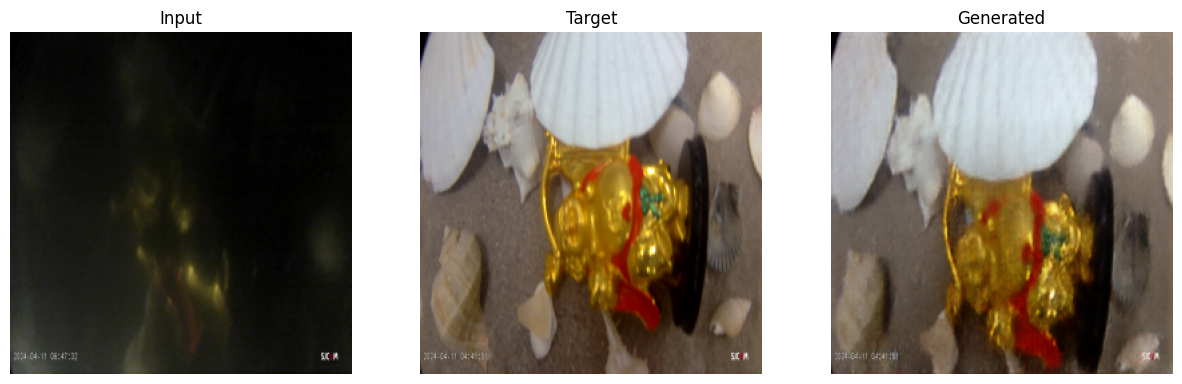

In [5]:
import matplotlib.pyplot as plt

#Start with empty variable to store the file path later
input_img = None
target_img = None
gen_img = None

#look inside the folder and subfolder
for root, dirs, files in os.walk(dataset):
    for file in files: #Check each file one by one

        if "_input.png" in file and input_img is None:  # If it's an input file and we haven't saved one yet
            input_img = os.path.join(root, file)  # Save the full folder path and filename together

        elif "_target.png" in file and target_img is None:  # If it's a target file and we haven't saved one yet
            target_img = os.path.join(root, file)   # Save the full folder path and filename together

        elif "_gen.png" in file and gen_img is None: # If it's a generated file and we haven't saved one yet
            gen_img = os.path.join(root, file)   # Save the full folder path and filename together

        if input_img and target_img and gen_img:  # Inside the file loop: stop checking files if we found all three
            break
    if input_img and target_img and gen_img:  # Inside the folder loop: stop searching folders if we found all three
        break

# Display images
plt.figure(figsize=(15, 5))
images = [input_img, target_img, gen_img]
titles = ["Input", "Target", "Generated"]

for i in range(3):
    img = Image.open(images[i])
    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(titles[i])
    plt.axis("off")
plt.show()

In [6]:
# Take one input image
import numpy as np
for root, dirs, files in os.walk(dataset):
   for file in files:
     if "_input.png" in file:

       path = os.path.join(root, file)
       # Open image
       img = Image.open(path).convert("RGB")

       # Resize
       img = img.resize((256, 256))

       # Convert to NumPy array
       img_array = np.array(img)

       # Normalize pixels from 0-255 to 0-1
       img_array = img_array / 255.0

       print("Original size:", Image.open(path).size)
       print("New size:", img.size)
       print("Pixel range:", img_array.min(), "to", img_array.max())
       break
   else:
        continue
   break

Original size: (256, 256)
New size: (256, 256)
Pixel range: 0.0 to 0.9764705882352941


In [7]:
#Check corrupted images
from PIL import Image
from pathlib import Path

folder = Path("/content/images")

images = list(folder.rglob("*.png"))
corrupted = []

for img in images:
    try:
        with Image.open(img) as im:
            im.verify()
    except:
        corrupted.append(img)

print("Corrupted images:", len(corrupted))

for img in corrupted:
    print(img)

Corrupted images: 0


# Day 8

In [8]:
#Check Input / Target / Generated images
inputs = list(folder.rglob("*_input.png"))
targets = list(folder.rglob("*_target.png"))
generated = list(folder.rglob("*_gen.png"))

print("Input images:", len(inputs))
print("Target images:", len(targets))
print("Generated images:", len(generated))

Input images: 1078
Target images: 1078
Generated images: 1078


In [9]:
#Count images
import os

dataset = "/content/images" # Corrected dataset path

#intialize to 0
input_count = 0
target_count = 0
gen_count = 0

#look inside the folder and subfolder
for root, dirs, files in os.walk(dataset):

    for file in files: #check each file one by one

        if "_input.png" in file:  #if file name is "_input.png" input_count increase with 1
            input_count = input_count + 1

        elif "_target.png" in file:  #if file name is "_target.png" target_count increase with 1
            target_count = target_count + 1

        elif "_gen.png" in file:
            gen_count = gen_count + 1

#shows the final count
print("Input images:", input_count)
print("Target images:", target_count)
print("Generated images:", gen_count)
#counts the total
print("Total:", input_count + target_count + gen_count)

Input images: 1078
Target images: 1078
Generated images: 1078
Total: 3234


In [10]:
#Check missing Input–Target pairs
input_ids = {x.stem.replace("_input", "") for x in inputs}
target_ids = {x.stem.replace("_target", "") for x in targets}

missing_targets = input_ids - target_ids
missing_inputs = target_ids - input_ids

print("Inputs without targets:", len(missing_targets))
print("Targets without inputs:", len(missing_inputs))

Inputs without targets: 0
Targets without inputs: 0


In [11]:
#Check filename consistency
other_files = []

for img in images:
    name = img.stem

    if not ("_input" in name or "_target" in name or "_gen" in name):
        other_files.append(img)

print("Files not following input/target/gen naming:", len(other_files))

for img in other_files:
    print(img)

Files not following input/target/gen naming: 0


In [12]:
import os

dataset = "/content/images"

all_images = []
input_images = []
target_images = []
generated_images = []

for root, dirs, files in os.walk(dataset):
    for file in files:

        if file.endswith(".png"):
            all_images.append(file)

            if "_input.png" in file:
                input_images.append(file)

            elif "_target.png" in file:
                target_images.append(file)

            elif "_gen.png" in file:
                generated_images.append(file)

# Find images that do not match the expected naming pattern
unmatched = []

for file in all_images:
    if not ("_input.png" in file or
            "_target.png" in file or
            "_gen.png" in file):
        unmatched.append(file)

print("Total images:", len(all_images))
print("Input:", len(input_images))
print("Target:", len(target_images))
print("Generated:", len(generated_images))

print("\nUnmatched images:")
for file in unmatched:
    print(file)


Total images: 3235
Input: 1078
Target: 1078
Generated: 1078

Unmatched images:
img 74_input - Copy.png


In [13]:
for root, dirs, files in os.walk(dataset):
    for file in files:
        if file in unmatched:
            print("Location:", os.path.join(root, file))



Location: /content/images/epoch_0110/img 74_input - Copy.png


In [14]:
from PIL import Image
import os

folder = "/content/images/epoch_0110"

for file in os.listdir(folder):
    if "74" in file:
        path = os.path.join(folder, file)

        try:
            img = Image.open(path)
            print(file, "→", img.size)
        except:
            pass


img 74_input - Copy.png → (256, 256)
img 74_target.png → (256, 256)
img 74_input.png → (256, 256)
img 74_gen.png → (256, 256)


# Day 10

In [15]:
import os
import numpy as np
from PIL import Image

dataset = "/content/images"

input_count = 0 # Initialize a counter for input images
target_count = 0 # Initialize a counter for target images
gen_count = 0 # Initialize a counter for generated images

widths = [] # List to store image widths
heights = [] # List to store image heights
brightness = [] # List to store image brightness values

# Walk through all directories and files in the dataset folder
for root, dirs, files in os.walk(dataset):
    for file in files:
        if not file.endswith(".png"): # Skip any files that are not PNG images
            continue

        path = os.path.join(root, file)

        try:
            # Open the image and convert it to RGB format
            img = Image.open(path).convert("RGB")
            arr = np.array(img)

            widths.append(img.width) # Add the image width to the list
            heights.append(img.height) # Add the image height to the list
            brightness.append(arr.mean()) # Calculate and add the average brightness (mean pixel value) to the list

            if "_input.png" in file: # Check if the file name indicates an input image
                input_count += 1 # Increment the input image counter
            elif "_target.png" in file: # Check if the file name indicates a target image
                target_count += 1 # Increment the target image counter
            elif "_gen.png" in file: # Check if the file name indicates a generated image
                gen_count += 1 # Increment the generated image counter

        except:
            pass # For corrupted images

print("Input images:", input_count)
print("Target images:", target_count)
print("Generated images:", gen_count)

print("\nImage size:")
# Print the minimum and maximum observed widths of the images
print("Width:", min(widths), "to", max(widths))
# Print the minimum and maximum observed heights of the images
print("Height:", min(heights), "to", max(heights))

print("\nAverage brightness:", round(np.mean(brightness), 2)) # Print the average brightness
print("Minimum brightness:", round(np.min(brightness), 2)) # Print the minimum brightness
print("Maximum brightness:", round(np.max(brightness), 2)) # Print the maximum brightness

Input images: 1078
Target images: 1078
Generated images: 1078

Image size:
Width: 256 to 256
Height: 256 to 256

Average brightness: 108.42
Minimum brightness: 0.97
Maximum brightness: 252.12


In [16]:
# Initialize an empty dictionary to store image pairs
pairs = {}

# Walk through all directories and files in the dataset folder
for root, dirs, files in os.walk(dataset):
    for file in files:
        if file.endswith(".png"): # Process only PNG image files

            if "_input.png" in file: # If the file is an input image
                # Extract a common key from the filename
                key = file.replace("_input.png", "")
                # Add the input image path to the 'pairs' dictionary
                pairs.setdefault(key, {})["input"] = os.path.join(root, file)

            elif "_target.png" in file: # If the file is a target image
                # Extract a common key from the filename
                key = file.replace("_target.png", "")
                # Add the target image path to the 'pairs' dictionary
                pairs.setdefault(key, {})["target"] = os.path.join(root, file)

            elif "_gen.png" in file: # If the file is a generated image
                # Extract a common key from the filename
                key = file.replace("_gen.png", "")
                # Add the generated image path to the 'pairs' dictionary
                pairs.setdefault(key, {})["generated"] = os.path.join(root, file)

Complete pairs found: 312


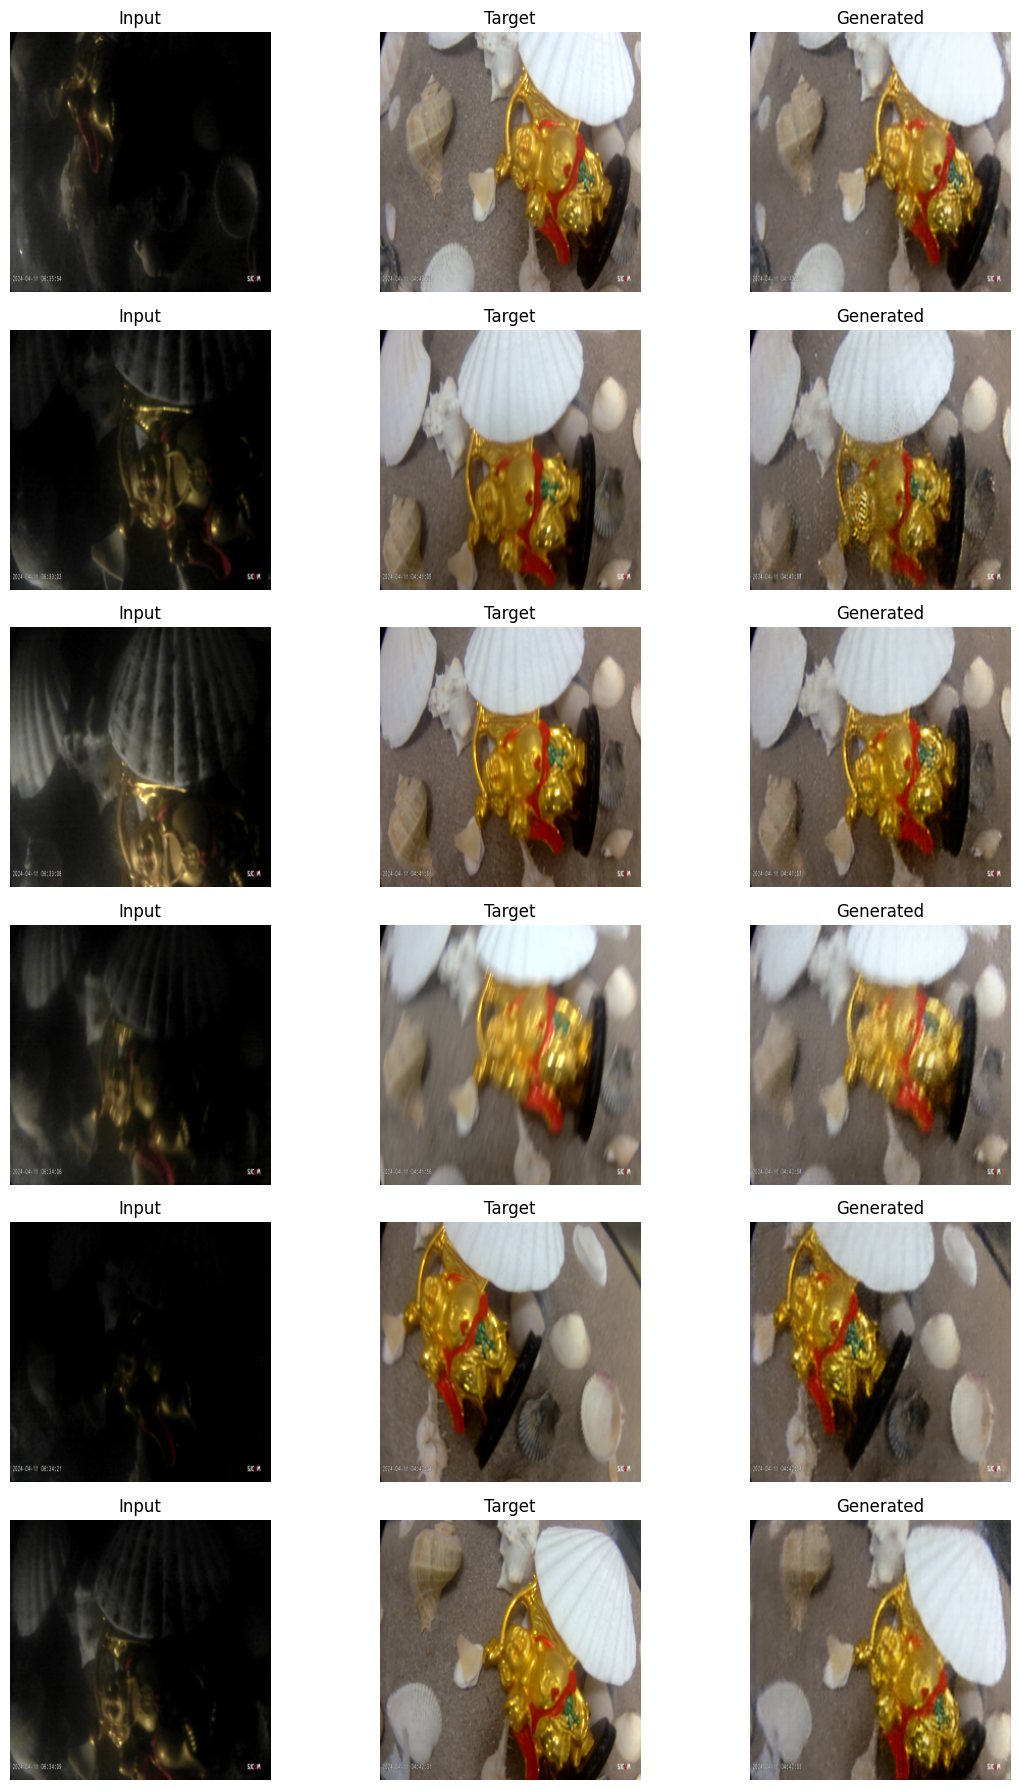

In [17]:
import matplotlib.pyplot as plt
# Filter the 'pairs' dictionary to keep only entries where 'input', 'target', and 'generated' images are all present
complete_pairs = [
    p for p in pairs.values()
    if "input" in p and "target" in p and "generated" in p # Check if all three keys exist in the current dictionary
]

print("Complete pairs found:", len(complete_pairs))

# Determine how many pairs to display (up to a maximum of 6)
n = min(6, len(complete_pairs))

plt.figure(figsize=(12, 3 * n))

for i in range(n):
    p = complete_pairs[i]

    plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(Image.open(p["input"]))
    plt.title("Input")
    plt.axis("off")

    plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(Image.open(p["target"]))
    plt.title("Target")
    plt.axis("off")

    plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(Image.open(p["generated"]))
    plt.title("Generated")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
# Initialize empty lists to store brightness and contrast values of input images
brightness = []
contrast = []

# Walk through all directories and files in the dataset folder
for root, dirs, files in os.walk(dataset):
    for file in files:

        if "_input.png" in file: # Check if the file is an input image
            path = os.path.join(root, file) # Construct the full path to the image

            try:
                img = Image.open(path).convert("L")
                arr = np.array(img)

                brightness.append(arr.mean()) # Calculate and append the mean pixel value (brightness)
                contrast.append(arr.std()) # Calculate and append the standard deviation of pixel values (contrast)

            except:
                pass # If an error occurs

print("Number of input images:", len(brightness))

print("\nBrightness")
print("Average:", round(np.mean(brightness), 2))
print("Minimum:", round(np.min(brightness), 2))
print("Maximum:", round(np.max(brightness), 2))

print("\nContrast")
print("Average:", round(np.mean(contrast), 2))
print("Minimum:", round(np.min(contrast), 2))
print("Maximum:", round(np.max(contrast), 2))

Number of input images: 1078

Brightness
Average: 70.16
Minimum: 1.03
Maximum: 246.69

Contrast
Average: 26.68
Minimum: 2.19
Maximum: 73.32


In [19]:
# Initialize an empty list to store brightness and path for darkest images
darkest = []

# Walk through all directories and files in the dataset folder
for root, dirs, files in os.walk(dataset):
    for file in files:

        if "_input.png" in file: # Check if the file is an input image
            path = os.path.join(root, file) # Construct the full path to the image

            try:
                img = Image.open(path).convert("L")
                arr = np.array(img)

                # Append a tuple of (mean brightness, image path) to the list
                darkest.append((arr.mean(), path))

            except:
                pass # If an error occurs

darkest.sort() # Sort the list based on brightness

print("5 darkest input images:\n")

# Iterate through the first 5 elements
for value, path in darkest[:5]:
    print(round(value, 2), "→", path)

5 darkest input images:

1.03 → /content/images/epoch_0110/img 58_input.png
2.69 → /content/images/epoch_0110/img 140_input.png
3.65 → /content/images/epoch_0110/img 57_input.png
4.07 → /content/images/epoch_0110/img 141_input.png
4.21 → /content/images/epoch_0110/img 59_input.png


In [20]:
# Initialize an empty list to store contrast and path for lowest contrast images
low_contrast = []

# Walk through all directories and files in the dataset folder
for root, dirs, files in os.walk(dataset):
    for file in files:

        if "_input.png" in file: # Check if the file is an input image
            path = os.path.join(root, file) # Construct the full path to the image

            try:
                img = Image.open(path).convert("L")
                arr = np.array(img)

                # Append a tuple of (standard deviation of pixels, image path) to the list
                low_contrast.append((arr.std(), path))

            except:
                pass # If an error occurs

low_contrast.sort() # Sort the list based on contrast

print("5 lowest-contrast input images:\n")

# Iterate through the first 5 elements
for value, path in low_contrast[:5]:
    print(round(value, 2), "→", path)

5 lowest-contrast input images:

2.19 → /content/images/epoch_0096/img_22_input.png
2.19 → /content/images/epoch_0096/img_25_input.png
2.25 → /content/images/epoch_0096/img_23_input.png
2.47 → /content/images/epoch_0096/img_24_input.png
3.06 → /content/images/epoch_0096/img_14_input.png


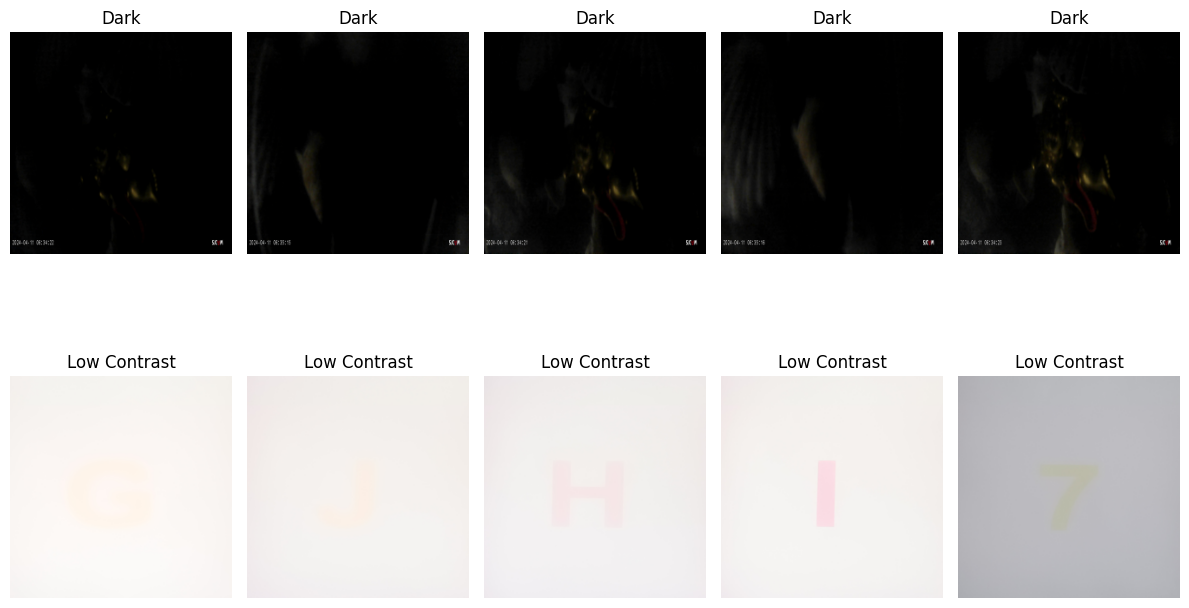

In [21]:
#Visualize the Darkest and Lowest-contrast image
import os
import matplotlib.pyplot as plt
from PIL import Image

darkest = [
    "/content/images/epoch_0110/img 58_input.png",
    "/content/images/epoch_0110/img 140_input.png",
    "/content/images/epoch_0110/img 57_input.png",
    "/content/images/epoch_0110/img 141_input.png",
    "/content/images/epoch_0110/img 59_input.png"
]

low_contrast = [
    "/content/images/epoch_0096/img_22_input.png",
    "/content/images/epoch_0096/img_25_input.png",
    "/content/images/epoch_0096/img_23_input.png",
    "/content/images/epoch_0096/img_24_input.png",
    "/content/images/epoch_0096/img_14_input.png"
]

plt.figure(figsize=(12, 8))

for i, path in enumerate(darkest):
    plt.subplot(2, 5, i + 1)
    plt.imshow(Image.open(path))
    plt.title("Dark")
    plt.axis("off")

for i, path in enumerate(low_contrast):
    plt.subplot(2, 5, i + 6)
    plt.imshow(Image.open(path))
    plt.title("Low Contrast")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Day 11

In [22]:
import os
import shutil
import random

source = "/content/images" # Define the source directory
output = "/content/Dataset_v1" # Define the output directory where the prepared dataset will be stored

random.seed(42) # Set a random seed for reproducibility

# Create folders for train, validation, and test sets, each with 'input' and 'target' subfolders
for split in ["train", "val", "test"]:
    for kind in ["input", "target"]:

        os.makedirs(f"{output}/{split}/{kind}", exist_ok=True)

# Find input-target pairs by scanning the source directory
pairs = {}

# os.walk generates file names in a directory tree
for root, dirs, files in os.walk(source):
    for file in files:

        # Check if the file is an input image
        if file.endswith("_input.png"):
            key = file.replace("_input.png", "") # Extract a common key for pairing (e.g., 'img_1' from 'img_1_input.png')
            pairs.setdefault(key, {})["input"] = os.path.join(root, file)

        # Check if the file is a target image
        elif file.endswith("_target.png"):
            key = file.replace("_target.png", "") # Extract the common key
            # Add the target image path to the corresponding key
            pairs.setdefault(key, {})["target"] = os.path.join(root, file)

# Filter the collected pairs to ensure only complete input-target pairs are kept
pairs = [
    p for p in pairs.values() # Iterate through the values of the 'pairs' dictionary
    if "input" in p and "target" in p # Keep only those dictionaries that contain both 'input' and 'target' keys
]

print("Valid input-target pairs:", len(pairs))


random.shuffle(pairs)

# Define the split ratios for training, validation, and test sets
n = len(pairs)

train_end = int(0.70 * n) # Calculate the end index for the training set 70%
val_end = int(0.85 * n) # Calculate the end index for the validation set (15% + 70% = 85%)

train_pairs = pairs[:train_end]
val_pairs = pairs[train_end:val_end]
test_pairs = pairs[val_end:] # Slice the list to get test pairs (remaining 15%)

print("Train:", len(train_pairs))
print("Validation:", len(val_pairs))
print("Test:", len(test_pairs))

# Define a helper function to copy image pairs to their respective split directories
def copy_pairs(data, split):

    for i, pair in enumerate(data):

        # Copy the input image to the corresponding split's input folder
        shutil.copy(
            pair["input"],
            f"{output}/{split}/input/{i}.png"
        )

        # Copy the target image to the corresponding split's target folder
        shutil.copy(
            pair["target"],
            f"{output}/{split}/target/{i}.png"
        )

# Call the copy_pairs function for each split to organize the dataset
copy_pairs(train_pairs, "train") # Copy training pairs
copy_pairs(val_pairs, "val") # Copy validation pairs
copy_pairs(test_pairs, "test") # Copy test pairs

print("\nDataset V1 created successfully!")

Valid input-target pairs: 312
Train: 218
Validation: 47
Test: 47

Dataset V1 created successfully!


In [23]:
#Resize and Normalize
from PIL import Image
import numpy as np
import os

dataset = "/content/Dataset_v1"

# Define a function to load, resize, and normalize an image
def load_image(path):
    # Open the image from the given path and convert it to RGB format
    img = Image.open(path).convert("RGB")
    # Resize the image to 256x256 pixels. This ensures all images have a consistent size.
    img = img.resize((256, 256))

    img = np.array(img, dtype=np.float32)
    # Normalize the pixel values from the 0-255 range to the 0.0-1.0 range
    img = img / 255.0

    return img


# Define paths to a sample input and target image from the training set
input_path = dataset + "/train/input/0.png"
target_path = dataset + "/train/target/0.png"

# Load and process the sample input image
x = load_image(input_path)
# Load and process the sample target image
y = load_image(target_path)

print("Input shape:", x.shape)
print("Target shape:", y.shape)

print("Input pixel range:", x.min(), "to", x.max())
print("Target pixel range:", y.min(), "to", y.max())

Input shape: (256, 256, 3)
Target shape: (256, 256, 3)
Input pixel range: 0.43529412 to 0.6901961
Target pixel range: 0.019607844 to 1.0


In [24]:
#Create Dataset Loader
import torch
from torch.utils.data import Dataset, DataLoader # Tools for creating custom datasets and loading data in batches
from PIL import Image
import os
import numpy as np

# Define a custom dataset class that inherits from torch.utils.data.Dataset
class UnderwaterDataset(Dataset):

    # The constructor for the dataset class
    def __init__(self, folder):
        # Define the paths to the input and target image folders
        self.input_folder = folder + "/input"
        self.target_folder = folder + "/target"

        # Get a sorted list of all file names in the input folder
        self.files = sorted(os.listdir(self.input_folder))

    # Returns the total number of items in the dataset
    def __len__(self):
        return len(self.files)

    # Returns an item (input image and target image pair) at a given index
    def __getitem__(self, index):

        # Get the file name for the current index
        name = self.files[index]

        # Open the input image using its full path and convert it to RGB format
        input_img = Image.open(
            self.input_folder + "/" + name
        ).convert("RGB")

        # Open the target image using its full path and convert it to RGB format
        target_img = Image.open(
            self.target_folder + "/" + name
        ).convert("RGB")

        # Convert the images from PIL Image format to NumPy arrays and normalize pixel values to be between 0 and 1
        input_img = np.array(input_img, dtype=np.float32) / 255.0
        target_img = np.array(target_img, dtype=np.float32) / 255.0

        # Change the image dimension order from H,W,C (Height, Width, Channels) to C,H,W (Channels, Height, Width)
        input_img = torch.tensor(input_img).permute(2, 0, 1)
        target_img = torch.tensor(target_img).permute(2, 0, 1)

        return input_img, target_img


# Create instances of our custom dataset for training, validation, and testing
# The paths point to the respective folders where the prepared images are stored
train_data = UnderwaterDataset(
    "/content/Dataset_v1/train"
)

val_data = UnderwaterDataset(
    "/content/Dataset_v1/val"
)

test_data = UnderwaterDataset(
    "/content/Dataset_v1/test"
)

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))

# Create DataLoaders for each dataset
train_loader = DataLoader(
    train_data, # The dataset to load from
    batch_size=8, # Number of samples per batch
    shuffle=True # Shuffle the data every epoch for training
)

val_loader = DataLoader(
    val_data, # The validation dataset
    batch_size=8, # Number of samples per batch
    shuffle=False # No need to shuffle validation data
)

test_loader = DataLoader(
    test_data, # The test dataset
    batch_size=8, # Number of samples per batch
    shuffle=False # No need to shuffle test data
)

# Test the data loader by getting one batch from the training loader
x, y = next(iter(train_loader))

print("Input batch shape:", x.shape) # [batch_size, channels, height, width]
print("Target batch shape:", y.shape)

Train: 218
Validation: 47
Test: 47
Input batch shape: torch.Size([8, 3, 256, 256])
Target batch shape: torch.Size([8, 3, 256, 256])


In [25]:
# Create V1 configuration
import json

config = {
    "version": "V1",
    "image_size": [256, 256],
    "image_format": "PNG",
    "channels": 3,
    "normalization": "0-1",
    "train_pairs": 218,
    "validation_pairs": 47,
    "test_pairs": 47,
    "total_pairs": 312,
    "batch_size": 8,
    "augmentation": "None",
    "split": {
        "train": "70%",
        "validation": "15%",
        "test": "15%"
    },
    "random_seed": 42
}

with open(
    "/content/Dataset_v1/preprocessing_config_v1.json",
    "w"
) as f:
    json.dump(config, f, indent=4)

print("Preprocessing configuration saved!")

Preprocessing configuration saved!


# DAY 13

In [26]:
# 3 classical methods
import cv2
import numpy as np
import os
from PIL import Image

input_dir = "/content/Dataset_v1/train/input"
target_dir = "/content/Dataset_v1/train/target"

# Create output folders to store the results of each classical method.
os.makedirs("/content/classical_results/histogram_equalization", exist_ok=True)
os.makedirs("/content/classical_results/clahe", exist_ok=True)
os.makedirs("/content/classical_results/gamma", exist_ok=True)
os.makedirs("/content/classical_results/white_balance", exist_ok=True)


# Histogram Equalization
def apply_histogram_equalization(img):
    ycrcb = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb) # Convert RGB to YCrCb
    y, cr, cb = cv2.split(ycrcb) # Separate luminance channel
    y = cv2.equalizeHist(y) # Apply Histogram Equalization
    result = cv2.merge((y, cr, cb))   # Merge channels
    return cv2.cvtColor(result, cv2.COLOR_YCrCb2RGB)  # Convert back to RGB


# CLAHE (Contrast Limited Adaptive Histogram Equalization)
def apply_clahe(img):
    # Convert the image from RGB to LAB color space (L=lightness, A=green-red, B=blue-yellow).
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    # Split the LAB image into its individual L, A, and B channels.
    l, a, b = cv2.split(lab)

    # Create a CLAHE object with a clip limit of 2.0 and a tile grid size of 8x8.
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    # Apply CLAHE to the L (lightness) channel to enhance contrast.
    l = clahe.apply(l)

    # Merge the enhanced L channel back with the original A and B channels.
    # Convert the LAB image back to RGB color space and return it.
    return cv2.cvtColor(
        cv2.merge((l, a, b)),
        cv2.COLOR_LAB2RGB
    )


# Gamma Correction
def apply_gamma(img, gamma=1.2):
    # Create a lookup table (LUT) for gamma correction.
    # Each pixel value (0-255) is adjusted based on the gamma value.
    table = np.array([
        ((i / 255.0) ** (1 / gamma)) * 255  # Calculate the new pixel value using the gamma formula.
        for i in np.arange(256)  # Iterate through all possible pixel values (0 to 255).
    ]).astype("uint8")  # Ensure the LUT contains 8-bit unsigned integers.

    # Apply the gamma correction using the lookup table to the image.
    return cv2.LUT(img, table)


# White Balance
def apply_white_balance(img):
    # Convert the image from RGB to LAB color space.
    result = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)

    # Calculate the average values for the 'a' (green-red) and 'b' (blue-yellow) channels.
    avg_a = np.mean(result[:, :, 1])
    avg_b = np.mean(result[:, :, 2])

    # Adjust the 'a' channel based on its average and the lightness (L) channel.
    result[:, :, 1] = result[:, :, 1] - (
        (avg_a - 128) * (result[:, :, 0] / 255.0) * 1.1
    )

    # Adjust the 'b' channel based on its average and the lightness (L) channel.
    result[:, :, 2] = result[:, :, 2] - (
        (avg_b - 128) * (result[:, :, 0] / 255.0) * 1.1
    )

    # Convert the balanced LAB image back to RGB color space and return it.
    return cv2.cvtColor(result, cv2.COLOR_LAB2RGB)


# Apply methods to all images in the input directory.
for file in os.listdir(input_dir):

    # Skip files that are not PNG images.
    if not file.endswith(".png"):
        continue

    # Construct the full path to the current input image.
    path = os.path.join(input_dir, file)

    # Open the image using Pillow, convert to RGB, and then to a NumPy array.
    img = np.array(Image.open(path).convert("RGB"))

    result = apply_histogram_equalization(img)

    clahe = apply_clahe(img)

    gamma = apply_gamma(img)

    wb = apply_white_balance(img)

    # Save the processed image to its respective output folder.
    Image.fromarray(result).save(
        "/content/classical_results/histogram_equalization/" + file
    )

    Image.fromarray(clahe).save(
        "/content/classical_results/clahe/" + file
    )

    Image.fromarray(gamma).save(
        "/content/classical_results/gamma/" + file
    )

    Image.fromarray(wb).save(
        "/content/classical_results/white_balance/" + file
    )

print("Classical enhancement completed!")

Classical enhancement completed!


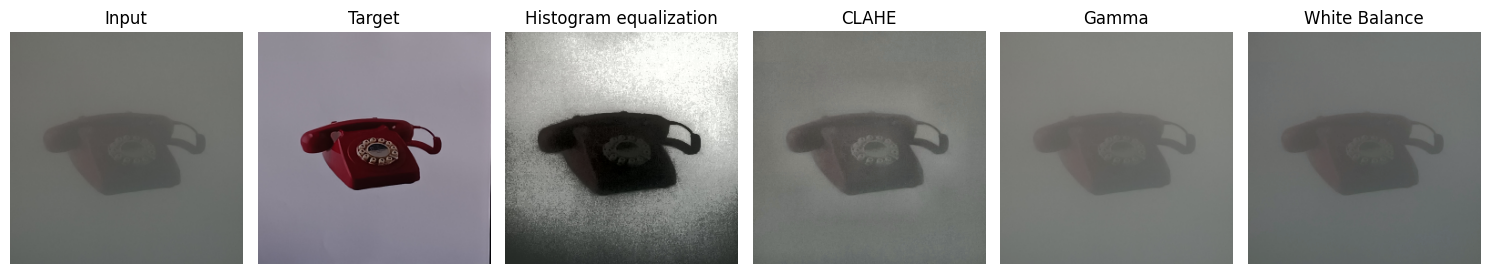

In [27]:
# Visual comparison
import matplotlib.pyplot as plt
from PIL import Image

file = os.listdir(input_dir)[0]

input_img = Image.open(input_dir + "/" + file)
target_img = Image.open(target_dir + "/" + file)
he_img = Image.open("/content/classical_results/histogram_equalization/" + file)
clahe_img = Image.open("/content/classical_results/clahe/" + file)
gamma_img = Image.open("/content/classical_results/gamma/" + file)
wb_img = Image.open("/content/classical_results/white_balance/" + file)

images = [
    input_img,
    target_img,
    he_img,
    clahe_img,
    gamma_img,
    wb_img
]

titles = [
    "Input",
    "Target",
    "Histogram equalization",
    "CLAHE",
    "Gamma",
    "White Balance"
]

plt.figure(figsize=(15, 4))

for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
# calculate PSNR + SSIM
import os
import cv2
import numpy as np
from skimage.metrics import peak_signal_noise_ratio, structural_similarity  # Import PSNR and SSIM metrics from scikit-image.

input_dir = "/content/Dataset_v1/train/input"
target_dir = "/content/Dataset_v1/train/target"

methods = {  # Dictionary mapping method names to their respective output folders.
    "Histogram Equalization":"/content/classical_results/histogram_equalization",
    "CLAHE": "/content/classical_results/clahe",
    "Gamma": "/content/classical_results/gamma",
    "White Balance": "/content/classical_results/white_balance"
}

results = {}  # Initialize an empty dictionary to store the PSNR and SSIM scores for each method.

for method, folder in methods.items():  # Loop through each classical enhancement method.
    psnr_values = []  # Initialize a list to store PSNR values for the current method.
    ssim_values = []  # Initialize a list to store SSIM values for the current method.

    for file in os.listdir(input_dir):  # Loop through each image file in the input directory.
        if not file.endswith(".png"):  # Skip files that are not PNG images.
            continue

        target_path = os.path.join(target_dir, file)  # path to the corresponding target image.
        result_path = os.path.join(folder, file)  # path to the processed image by the current method.

        if not os.path.exists(target_path) or not os.path.exists(result_path):  # Skip if either target or result image is missing.
            continue

        target = cv2.imread(target_path)  # Read the target image using OpenCV.
        result = cv2.imread(result_path)  # Read the processed image using OpenCV.

        target = cv2.cvtColor(target, cv2.COLOR_BGR2RGB)  # Convert target image from BGR (OpenCV default) to RGB.
        result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)  # Convert result image from BGR to RGB.

        # Calculate Peak Signal-to-Noise Ratio (PSNR) between the target and result images.
        # data_range=255 indicates that pixel values are in the 0-255 range.
        psnr = peak_signal_noise_ratio(target, result, data_range=255)

        # Calculate Structural Similarity Index (SSIM) between the target and result images.
        # channel_axis=2 specifies that color channels are the last dimension (RGB).
        ssim = structural_similarity(
            target,
            result,
            channel_axis=2,
            data_range=255
        )

        psnr_values.append(psnr)
        ssim_values.append(ssim)

    # Store the average PSNR and SSIM for the current method in the 'results' dictionary.
    results[method] = {
        "PSNR": np.mean(psnr_values),
        "SSIM": np.mean(ssim_values)
    }

print("Classical Baseline Results")

for method, scores in results.items():  # Iterate through the calculated scores for each method.
    # Print the method name and its average PSNR and SSIM scores, formatted to two and four decimal places respectively.
    print(f"{method}: "f"PSNR = {scores['PSNR']:.2f}, "f"SSIM = {scores['SSIM']:.4f}")

Classical Baseline Results
Histogram Equalization: PSNR = 8.08, SSIM = 0.2225
CLAHE: PSNR = 10.46, SSIM = 0.3803
Gamma: PSNR = 10.28, SSIM = 0.4121
White Balance: PSNR = 9.92, SSIM = 0.3981


In [29]:
# Edge extraction + edge similarity
import os
import cv2
import numpy as np

input_dir = "/content/Dataset_v1/train/input"
target_dir = "/content/Dataset_v1/train/target"

methods = {  # Dictionary mapping method names to their respective output folders.
    "Histogram Equalization":"/content/classical_results/histogram_equalization",
    "CLAHE": "/content/classical_results/clahe",
    "Gamma": "/content/classical_results/gamma",
    "White Balance": "/content/classical_results/white_balance"
}

def edge_f1(result, target):  # Define a function to calculate the F1-score for edge similarity.
    # Convert both the result and target images to grayscale for edge detection.
    result_gray = cv2.cvtColor(result, cv2.COLOR_RGB2GRAY)
    target_gray = cv2.cvtColor(target, cv2.COLOR_RGB2GRAY)

    # Apply Canny edge detection to both grayscale images. Thresholds (100, 200) determine strong and weak edges.
    # The '> 0' converts the edge image to a boolean array where True indicates an edge pixel.
    result_edges = cv2.Canny(result_gray, 100, 200) > 0
    target_edges = cv2.Canny(target_gray, 100, 200) > 0

    # Calculate the number of true positives.
    true_positive = np.logical_and(result_edges, target_edges).sum()

    # Calculate Precision: (True Positives) / (True Positives + False Positives).
    # 1e-8 is added to avoid division by zero if no edges are detected.
    precision = true_positive / (result_edges.sum() + 1e-8)
    # Calculate Recall: (True Positives) / (True Positives + False Negatives).
    recall = true_positive / (target_edges.sum() + 1e-8)

    # Calculate the F1-score, which is the harmonic mean of precision and recall.
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return f1

results = {}

for method, folder in methods.items():  # Loop through each classical enhancement method.

    edge_scores = []  # Initialize a list to store edge F1-scores for the current method.

    for file in os.listdir(input_dir):  # Loop through each image file in the input directory.

        if not file.endswith(".png"):  # Skip files that are not PNG images.
            continue

        target_path = os.path.join(target_dir, file)  # path to the corresponding target image.
        result_path = os.path.join(folder, file)  # path to the processed image by the current method.

        if not os.path.exists(target_path) or not os.path.exists(result_path):  # Skip if either target or result image is missing.
            continue

        target = cv2.imread(target_path)  # Read the target image using OpenCV.
        result = cv2.imread(result_path)  # Read the processed image using OpenCV.

        target = cv2.cvtColor(target, cv2.COLOR_BGR2RGB)  # Convert target image from BGR (OpenCV default) to RGB.
        result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)  # Convert result image from BGR to RGB.

        score = edge_f1(result, target)  # Calculate the edge F1-score using the defined function.
        edge_scores.append(score)

    # Store the average edge F1-score for the current method in the 'results' dictionary.
    results[method] = np.mean(edge_scores)

print("Edge Preservation Results")

for method, score in results.items():  # Iterate through the calculated scores for each method.

    print(f"{method}: Edge F1 = {score:.4f}")

Edge Preservation Results
Histogram Equalization: Edge F1 = 0.0573
CLAHE: Edge F1 = 0.0600
Gamma: Edge F1 = 0.0441
White Balance: Edge F1 = 0.0443


# Day 16

In [30]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [31]:
base_path = "/content/Dataset_v1" # Define the base directory where the processed dataset is stored

train_input = base_path + "/train/input"
train_target = base_path + "/train/target"

val_input = base_path + "/val/input"
val_target = base_path + "/val/target"

test_input = base_path + "/test/input"
test_target = base_path + "/test/target"

In [32]:
class UnderwaterDataset(Dataset):

    def __init__(self, input_dir, target_dir): # Constructor for the dataset, taking paths to input and target image directories
        self.input_dir = input_dir # Store the input directory path
        self.target_dir = target_dir

        self.files = sorted(os.listdir(input_dir)) # Get a sorted list of all filenames in the input directory

        self.transform = transforms.ToTensor() # Initialize a transformation to convert PIL images to PyTorch tensors

    def __len__(self): # Method to return the total number of items in the dataset
        return len(self.files)

    def __getitem__(self, idx): # Method to retrieve an item (input and target image pair) at a given index

        filename = self.files[idx] # Get the filename for the current index

        input_img = Image.open( os.path.join(self.input_dir, filename) # Construct the full path to the input image
        ).convert("RGB") # Convert the input image to RGB format

        target_img = Image.open(os.path.join(self.target_dir, filename) # Construct the full path to the target image
        ).convert("RGB") # Convert the target image to RGB format

        # Histogram Equalization

        ycrcb = cv2.cvtColor(input_img,cv2.COLOR_RGB2YCrCb)
        y, cr, cb = cv2.split(ycrcb)
        y = cv2.equalizeHist(y)
        input_img = cv2.cvtColor(cv2.merge((y, cr, cb)),cv2.COLOR_YCrCb2RGB)

        input_img = self.transform(input_img) # Apply the ToTensor transformation to the input image
        target_img = self.transform(target_img)

        return input_img, target_img # Return the transformed input and target image tensors

In [33]:
train_dataset = UnderwaterDataset( # Create an instance of the UnderwaterDataset for the training data
    train_input, # Path to the input images for the training set
    train_target
)

val_dataset = UnderwaterDataset( # Create an instance of the UnderwaterDataset for the validation data
    val_input, # Path to the input images for the validation set
    val_target
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Training images: 218
Validation images: 47


In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Check if a CUDA-enabled GPU is available; if so, use it, otherwise use the CPU.

print("Device:", device)

Device: cuda


In [35]:
class CNN(nn.Module): # Define a class named CNN

    def __init__(self): # Constructor method for the CNN class
        super(CNN, self).__init__() # Call the constructor of the parent class (nn.Module)

        self.network = nn.Sequential( # Define a sequential container for the layers of the neural network

            # First Convolutional Block
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # Convolutional layer: 3 input channels (RGB), 32 output channels, 3x3 kernel, padding=1 to maintain spatial dimensions
            nn.ReLU(), # ReLU activation function to introduce non-linearity

            # Second Convolutional Block
            nn.Conv2d(32, 32, kernel_size=3, padding=1), # Another convolutional layer: 32 input channels, 32 output channels, 3x3 kernel, padding=1
            nn.ReLU(), # ReLU activation function

            # Output Convolutional Layer
            nn.Conv2d(32, 3, kernel_size=3, padding=1), # Output convolutional layer: 32 input channels, 3 output channels (for RGB image output), 3x3 kernel, padding=1
            nn.Sigmoid() # Sigmoid activation function to scale output pixel values between 0 and 1
        )

    def forward(self, x): # Defines the forward pass
        return self.network(x) # Pass the input 'x' through the defined sequential network


model = CNN().to(device) # Create an instance of the CNN model and move it to the specified device (GPU or CPU)

print(model)

CNN(
  (network): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Sigmoid()
  )
)


In [36]:
criterion = nn.MSELoss() # Define the loss function as Mean Squared Error (MSE)

optimizer = torch.optim.Adam( # Initialize the Adam optimizer.
    model.parameters(), # Tell the optimizer to adjust the parameters (weights and biases) of the 'model'.
    lr=0.001 # Set the learning rate to 0.001
)

In [37]:
epochs = 200 # Set the total number of training epochs

train_losses = []
val_losses = []

for epoch in range(epochs): # Loop through each epoch

    # Training phase
    model.train() # Set the model to training mode

    total_train_loss = 0 # Initialize total training loss for the current epoch

    for inputs, targets in train_loader: # Iterate over batches of training data

        inputs = inputs.to(device) # Move input images to the specified device
        targets = targets.to(device)

        optimizer.zero_grad() # Reset gradients from the previous iteration

        outputs = model(inputs) # Perform a forward pass to get model predictions

        loss = criterion(outputs, targets) # Calculate the loss between predictions and targets

        loss.backward() # Perform backpropagation to calculate gradients

        optimizer.step() # Update model parameters using the optimizer

        total_train_loss += loss.item() # Accumulate the loss for the current batch

    train_loss = total_train_loss / len(train_loader) # Calculate the average training loss for the epoch


    # Validation phase
    model.eval() # Set the model to evaluation mode

    total_val_loss = 0 # Initialize total validation loss for the current epoch

    with torch.no_grad(): # Disable gradient calculation during validation to save memory and speed up

        for inputs, targets in val_loader: # Iterate over batches of validation data

            inputs = inputs.to(device) # Move input images to the specified device
            targets = targets.to(device)

            outputs = model(inputs) # Perform a forward pass to get model predictions

            loss = criterion(outputs, targets) # Calculate the loss between predictions and targets

            total_val_loss += loss.item() # Accumulate the loss for the current batch

    val_loss = total_val_loss / len(val_loader) # Calculate the average validation loss for the epoch


    train_losses.append(train_loss) # Store the training loss for the current epoch
    val_losses.append(val_loss)


    print(f"Epoch {epoch+1}/{epochs} "
        f"- Train Loss: {train_loss:.4f} "
        f"- Val Loss: {val_loss:.4f}"
    )

Epoch 1/200 - Train Loss: 0.0843 - Val Loss: 0.0642
Epoch 2/200 - Train Loss: 0.0784 - Val Loss: 0.0561
Epoch 3/200 - Train Loss: 0.0723 - Val Loss: 0.0513
Epoch 4/200 - Train Loss: 0.0659 - Val Loss: 0.0528
Epoch 5/200 - Train Loss: 0.0643 - Val Loss: 0.0503
Epoch 6/200 - Train Loss: 0.0573 - Val Loss: 0.0475
Epoch 7/200 - Train Loss: 0.0565 - Val Loss: 0.0504
Epoch 8/200 - Train Loss: 0.0563 - Val Loss: 0.0467
Epoch 9/200 - Train Loss: 0.0590 - Val Loss: 0.0472
Epoch 10/200 - Train Loss: 0.0584 - Val Loss: 0.0471
Epoch 11/200 - Train Loss: 0.0601 - Val Loss: 0.0494
Epoch 12/200 - Train Loss: 0.0582 - Val Loss: 0.0481
Epoch 13/200 - Train Loss: 0.0570 - Val Loss: 0.0539
Epoch 14/200 - Train Loss: 0.0566 - Val Loss: 0.0484
Epoch 15/200 - Train Loss: 0.0572 - Val Loss: 0.0495
Epoch 16/200 - Train Loss: 0.0559 - Val Loss: 0.0465
Epoch 17/200 - Train Loss: 0.0597 - Val Loss: 0.0463
Epoch 18/200 - Train Loss: 0.0585 - Val Loss: 0.0468
Epoch 19/200 - Train Loss: 0.0555 - Val Loss: 0.0470
Ep

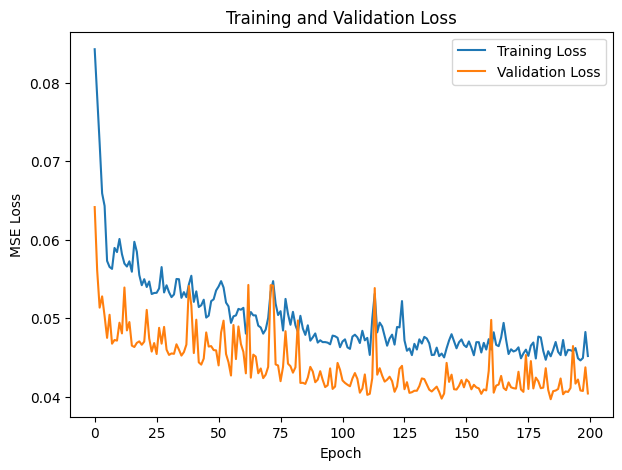

In [38]:
plt.figure(figsize=(7,5)) # width=7, height=5 inches

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")

plt.legend() # Display the legend, which uses the labels defined in plt.plot()
plt.show()

In [39]:
model.eval() # Set the model to evaluation mode.

inputs, targets = next(iter(val_loader)) # Get a batch of input and target images from the validation data loader.

inputs = inputs.to(device) # Move the input images to the specified device

with torch.no_grad(): # Disable gradient calculation for this block.
    outputs = model(inputs) # Pass the input images through the model to get the enhanced (output) images.

inputs = inputs.cpu() # Move the input images back to the CPU for visualization with matplotlib.
outputs = outputs.cpu() # Move the output images back to the CPU for visualization with matplotlib.

In [40]:
import torch
import numpy as np
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from skimage.filters import sobel

model.eval()

psnr_scores = []
ssim_scores = []
edge_scores = []

with torch.no_grad():

    for inputs, targets in val_loader:

        inputs = inputs.to(device)
        targets = targets.to(device)

        outputs = model(inputs)

        outputs = outputs.clamp(0, 1)

        # Batch images
        for pred, target in zip(outputs, targets):

            pred = pred.cpu().numpy().transpose(1, 2, 0)
            target = target.cpu().numpy().transpose(1, 2, 0)

            # PSNR
            psnr = peak_signal_noise_ratio(
                target, pred, data_range=1.0
            )

            # SSIM
            ssim = structural_similarity(
                target,
                pred,
                channel_axis=2,
                data_range=1.0
            )

            # Convert to grayscale
            pred_gray = np.mean(pred, axis=2)
            target_gray = np.mean(target, axis=2)

            # Sobel edges
            pred_edge = sobel(pred_gray)
            target_edge = sobel(target_gray)

            # Threshold edges
            pred_edge = pred_edge > 0.1
            target_edge = target_edge > 0.1

            # Edge F1
            tp = np.logical_and(pred_edge, target_edge).sum()
            fp = np.logical_and(pred_edge, ~target_edge).sum()
            fn = np.logical_and(~pred_edge, target_edge).sum()

            precision = tp / (tp + fp + 1e-8)
            recall = tp / (tp + fn + 1e-8)

            edge_f1 = 2 * precision * recall / (
                precision + recall + 1e-8
            )

            psnr_scores.append(psnr)
            ssim_scores.append(ssim)
            edge_scores.append(edge_f1)

print("CNN PSNR    :", round(np.mean(psnr_scores), 4))
print("CNN SSIM    :", round(np.mean(ssim_scores), 4))
print("CNN Edge F1 :", round(np.mean(edge_scores), 4))

CNN PSNR    : 14.6867
CNN SSIM    : 0.5551
CNN Edge F1 : 0.0345


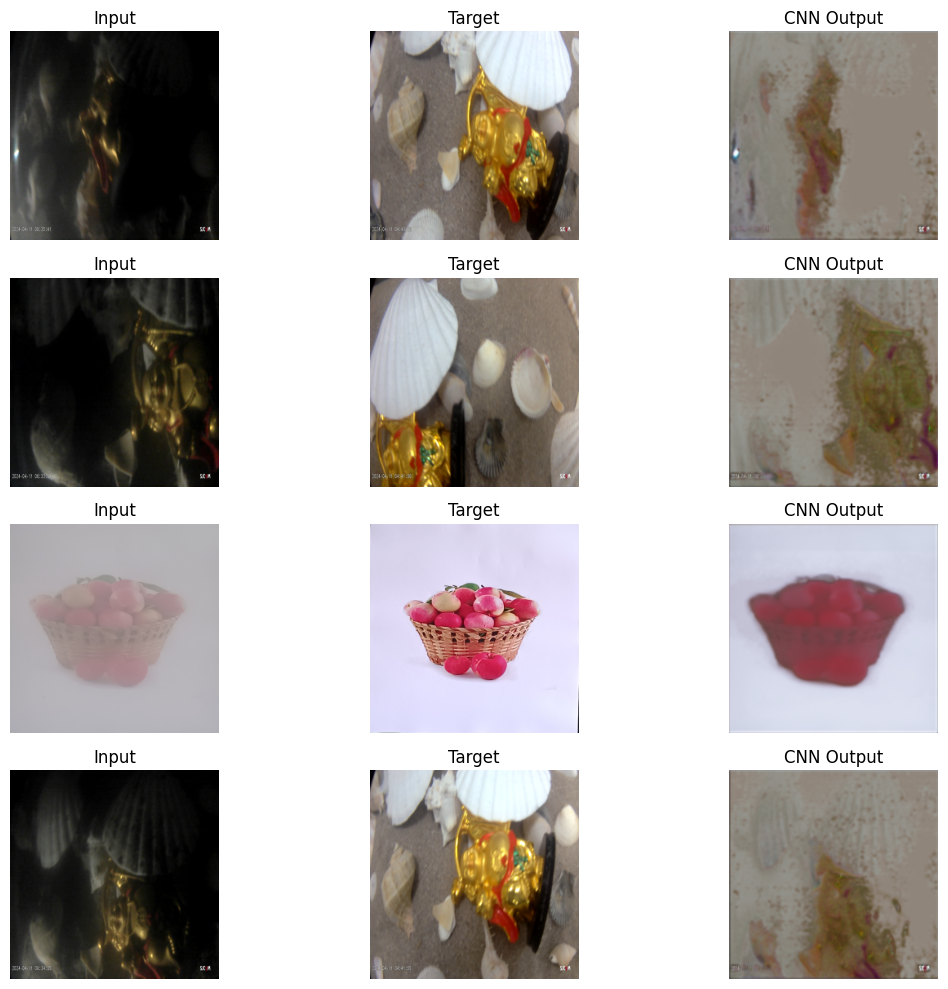

In [41]:
plt.figure(figsize=(12, 10))

for i in range(4): # Loop through the first 4 images in the batch

    # Display the Input image
    plt.subplot(4, 3, i*3 + 1)
    plt.imshow(inputs[i].cpu().permute(1, 2, 0)) # Display the input image
    plt.title("Input")
    plt.axis("off")

    # Display the Target image
    plt.subplot(4, 3, i*3 + 2)
    plt.imshow(targets[i].cpu().permute(1, 2, 0)) # Display the target image
    plt.title("Target")
    plt.axis("off")

    # Display the CNN Output image
    plt.subplot(4, 3, i*3 + 3)
    plt.imshow(outputs[i].cpu().permute(1, 2, 0)) # Display the image generated by the CNN model
    plt.title("CNN Output")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Day 17

In [42]:
import cv2
import numpy as np
import os
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

input_dir = "/content/Dataset_v1/val/input" # Define the directory path where validation input images are stored
target_dir = "/content/Dataset_v1/val/target" #

# Refinement CLAHE
candidates = {
    "CLAHE_1": (1.0, (8, 8)), # Candidate 1: clipLimit = 1.0, tileGridSize = 8x8
    "CLAHE_2": (2.0, (8, 8)), # Candidate 2: clipLimit = 2.0, tileGridSize = 8x8
    "CLAHE_3": (3.0, (8, 8)), # Candidate 3: clipLimit = 3.0, tileGridSize = 8x8
    "CLAHE_4": (2.0, (4, 4))  # Candidate 4: clipLimit = 2.0, tileGridSize = 4x4
}

In [43]:
# Apply CLAHE and calculate PSNR + SSIM
results = {} # Initialize an empty dictionary to store the evaluation results for each CLAHE candidate

for name, (clip, grid) in candidates.items(): # Iterate through each CLAHE candidate and its parameters

    psnr_scores = [] # Initialize a list to store PSNR scores for the current CLAHE candidate
    ssim_scores = []

    for file in os.listdir(input_dir): # Iterate through each image file in the input directory

        if not file.endswith(".png"): # Skip files that are not PNG images
            continue

        inp = np.array(Image.open(os.path.join(input_dir, file) # Construct the full path to the input image
        ).convert("RGB")) # Convert the input image to RGB format and then to a NumPy array

        target = np.array(Image.open(os.path.join(target_dir, file) # Construct the full path to the target image
        ).convert("RGB")) # Convert the target image to RGB format and then to a NumPy array

        lab = cv2.cvtColor(inp, cv2.COLOR_RGB2LAB) # Convert the input image from RGB to LAB color space
        l, a, b = cv2.split(lab) # Split the LAB image into its L (lightness), A (green-red), and B (blue-yellow) channels

        clahe = cv2.createCLAHE(clipLimit=clip, # Set the contrast limiting threshold
            tileGridSize=grid # Set the size of the grid for histogram equalization
        )

        l = clahe.apply(l) # Apply CLAHE to the L channel to enhance contrast

        output = cv2.cvtColor(cv2.merge((l, a, b)), # Merge the enhanced L channel with the original A and B channels
            cv2.COLOR_LAB2RGB # Specify the conversion from LAB to RGB
        )

        psnr_scores.append(peak_signal_noise_ratio( # Function to compute PSNR
                target, output, data_range=255 # Compare target and output images
            ))

        ssim_scores.append( # Calculate and store the SSIM score
            structural_similarity( # Function to compute SSIM
                target,
                output,
                channel_axis=2, # Specify that the color channels are along the third axis (index 2)
                data_range=255
            ))

    results[name] = [ # Store the mean PSNR and SSIM scores for the current CLAHE candidate
        np.mean(psnr_scores),
        np.mean(ssim_scores)
    ]

for name, scores in results.items(): # Iterate through the calculated results for each CLAHE candidate
    print(name,"PSNR =", round(scores[0], 4),"SSIM =", round(scores[1], 4))

CLAHE_1 PSNR = 11.0273 SSIM = 0.4245
CLAHE_2 PSNR = 11.2504 SSIM = 0.4122
CLAHE_3 PSNR = 11.4 SSIM = 0.3995
CLAHE_4 PSNR = 11.165 SSIM = 0.4169


In [44]:
def edge_f1(result, target):

    result_gray = cv2.cvtColor( # Convert the result image to grayscale
        result, cv2.COLOR_RGB2GRAY)

    target_gray = cv2.cvtColor( # Convert the target image to grayscale
        target, cv2.COLOR_RGB2GRAY)

    result_edges = cv2.Canny( # Apply Canny edge detection to the result image
        result_gray, 100, 200) > 0 # Edge detection with hysteresis thresholds

    target_edges = cv2.Canny( # Apply Canny edge detection to the target image
        target_gray, 100, 200) > 0 # Edge detection with hysteresis thresholds

    tp = np.logical_and( result_edges,target_edges).sum() # Calculate the number of true positives


    precision = tp / (result_edges.sum() + 1e-8) # Calculate precision
    recall = tp / (target_edges.sum() + 1e-8) # Calculate recall

    return 2 * precision * recall / ( precision + recall + 1e-8) # Calculate the F1-score


for name, (clip, grid) in candidates.items(): # Iterate through each CLAHE candidate and its parameters

    scores = [] # Initialize a list to store edge F1 scores for the current candidate

    for file in os.listdir(input_dir): # Iterate through each image file in the input directory

        if not file.endswith(".png"): # Skip non-PNG files
            continue

        inp = np.array(Image.open( # Open and convert input image to RGB NumPy array
            os.path.join(input_dir, file)
        ).convert("RGB"))

        target = np.array(Image.open( # Open and convert target image to RGB NumPy array
            os.path.join(target_dir, file)
        ).convert("RGB"))

        lab = cv2.cvtColor(inp, cv2.COLOR_RGB2LAB) # Convert input image to LAB color space
        l, a, b = cv2.split(lab) # Split LAB image into L, A, B channels

        clahe = cv2.createCLAHE( # Create a CLAHE object with specified clip limit and tile grid size
            clipLimit=clip,
            tileGridSize=grid
        )

        l = clahe.apply(l) # Apply CLAHE to the L channel

        output = cv2.cvtColor( # Merge channels and convert back to RGB
            cv2.merge((l, a, b)),
            cv2.COLOR_LAB2RGB
        )

        scores.append(edge_f1(output, target)) # Calculate and append the edge F1 score

    results[name].append(np.mean(scores))

print("\nRefinement Results")

for name, scores in results.items(): # Iterate through the results for each CLAHE candidate
    print(name,"PSNR =", round(scores[0], 4),"SSIM =", round(scores[1], 4),"Edge F1 =", round(scores[2], 4))


Refinement Results
CLAHE_1 PSNR = 11.0273 SSIM = 0.4245 Edge F1 = 0.0581
CLAHE_2 PSNR = 11.2504 SSIM = 0.4122 Edge F1 = 0.0642
CLAHE_3 PSNR = 11.4 SSIM = 0.3995 Edge F1 = 0.0688
CLAHE_4 PSNR = 11.165 SSIM = 0.4169 Edge F1 = 0.0635


In [45]:
best = max(
    results, # Iterate through the 'results' dictionary containing scores for each candidate
    key=lambda x: np.mean([ # The key for comparison is the mean of normalized scores (PSNR, SSIM, Edge F1)
        results[x][0] / max(r[0] for r in results.values()), # Normalize PSNR score by the maximum PSNR across all candidates
        results[x][1] / max(r[1] for r in results.values()),
        results[x][2] / max(r[2] for r in results.values())
    ])
)

print("Best refined method:", best)
print("PSNR:", results[best][0])
print("SSIM:", results[best][1])
print("Edge F1:", results[best][2])

Best refined method: CLAHE_3
PSNR: 11.399992951007219
SSIM: 0.39952759913453334
Edge F1: 0.06877115851395242


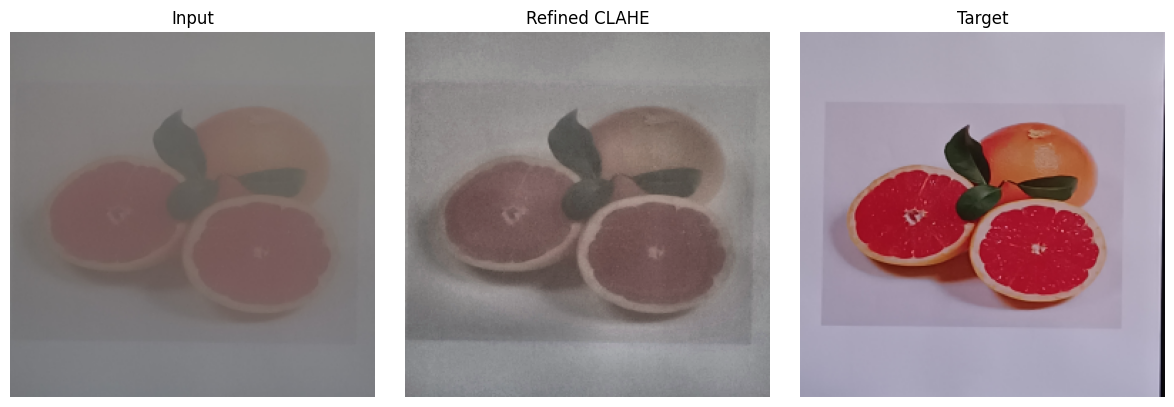

In [46]:
best_clip, best_grid = candidates[best] # Retrieve the clip limit and grid size parameters of the best performing CLAHE method.

file = os.listdir(input_dir)[0] # Select the first file from the input directory to demonstrate the best CLAHE method.

inp = np.array(Image.open(os.path.join(input_dir, file) # Construct the full path to the input image.
).convert("RGB")) # Convert the input image to RGB format and then to a NumPy array.

target = np.array(Image.open(os.path.join(target_dir, file) # Construct the full path to the target image.
).convert("RGB")) # Convert the target image to RGB format and then to a NumPy array.

lab = cv2.cvtColor(inp, cv2.COLOR_RGB2LAB) # Convert the input image from RGB to LAB color space.
l, a, b = cv2.split(lab)

clahe = cv2.createCLAHE(clipLimit=best_clip, # Set the contrast limiting threshold using the 'best_clip' parameter.
    tileGridSize=best_grid # Set the size of the grid for histogram equalization using the 'best_grid' parameter.
)

l = clahe.apply(l) # Apply CLAHE to the L (lightness) channel to enhance its contrast.

output = cv2.cvtColor(cv2.merge((l, a, b)),cv2.COLOR_LAB2RGB)  # Convert the processed image back to RGB color space.

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(inp)
plt.title("Input")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(output)
plt.title("Refined CLAHE")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(target)
plt.title("Target")
plt.axis("off")

plt.tight_layout()
plt.show()

# Day 19

In [50]:
import pandas as pd

# DAY 19: CNN parameter experiments

configs = [
    ("CNN_LR_0001", 0.0001),
    ("CNN_LR_001", 0.001),
    ("CNN_LR_01", 0.01)
]

cnn_log = []

for name, lr in configs:

    model = CNN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float("inf")

    for epoch in range(30):

        model.train()
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            output = model(inputs)
            loss = criterion(output, targets)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                output = model(inputs)
                val_loss += criterion(output, targets).item()

        val_loss /= len(val_loader)
        best_val_loss = min(best_val_loss, val_loss)

    cnn_log.append([name, lr, best_val_loss])

cnn_log = pd.DataFrame(
    cnn_log,
    columns=["Experiment", "Learning_Rate", "Best_Val_Loss"]
)

display(cnn_log)

,Experiment,Learning_Rate,Best_Val_Loss
0,CNN_LR_0001,0.0001,0.048259
1,CNN_LR_001,0.0010,0.044455
2,CNN_LR_01,0.0100,0.048967


In [51]:
best_cnn = cnn_log.loc[cnn_log["Best_Val_Loss"].idxmin()]

print("Best CNN:")
print(best_cnn)

Best CNN:
Experiment       CNN_LR_001
Learning_Rate         0.001
Best_Val_Loss      0.044455
Name: 1, dtype: object


In [52]:
# DAY 19 - CLAHE CONTROLLED EXPERIMENTS

import cv2
import os
import numpy as np
import pandas as pd
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

input_dir = "/content/Dataset_v1/val/input"
target_dir = "/content/Dataset_v1/val/target"

clahe_experiments = {
    "CLAHE-1": (2.0, (8, 8)),
    "CLAHE-2": (3.0, (8, 8)),
    "CLAHE-3": (4.0, (8, 8))
}

results = []

for name, (clip, grid) in clahe_experiments.items():

    psnr_scores = []
    ssim_scores = []

    for file in os.listdir(input_dir):

        if not file.endswith(".png"):
            continue

        inp = np.array(Image.open(os.path.join(input_dir, file)).convert("RGB"))

        target = np.array(Image.open(os.path.join(target_dir, file)).convert("RGB"))

        lab = cv2.cvtColor(inp,cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)

        clahe = cv2.createCLAHE(clipLimit=clip,tileGridSize=grid)

        l = clahe.apply(l)

        output = cv2.cvtColor(cv2.merge((l, a, b)),cv2.COLOR_LAB2RGB)

        psnr_scores.append(peak_signal_noise_ratio(target,output,data_range=255))

        ssim_scores.append(
            structural_similarity(
                target,
                output,
                channel_axis=2,
                data_range=255
            )
        )

    results.append({
        "Experiment": name,
        "Method": "Refined CLAHE",
        "Clip_Limit": clip,
        "Grid_Size": "8x8",
        "Validation_PSNR": np.mean(psnr_scores),
        "Validation_SSIM": np.mean(ssim_scores)
    })


clahe_df = pd.DataFrame(results)

print("CLAHE Experiment Results:")
display(clahe_df)

CLAHE Experiment Results:


,Experiment,Method,Clip_Limit,Grid_Size,Validation_PSNR,Validation_SSIM
0,CLAHE-1,Refined CLAHE,2.0,8x8,11.250439,0.412226
1,CLAHE-2,Refined CLAHE,3.0,8x8,11.399993,0.399528
2,CLAHE-3,Refined CLAHE,4.0,8x8,11.467432,0.384346


In [53]:
best_clahe = clahe_df.loc[
    clahe_df["Validation_PSNR"].idxmax()
]

print("Best CLAHE configuration:")
print(best_clahe)

Best CLAHE configuration:
Experiment               CLAHE-3
Method             Refined CLAHE
Clip_Limit                   4.0
Grid_Size                    8x8
Validation_PSNR        11.467432
Validation_SSIM         0.384346
Name: 2, dtype: object


In [54]:
import json

best_clahe_config = {
    "method": "Refined CLAHE",
    "clip_limit": float(best_clahe["Clip_Limit"]),
    "grid_size": best_clahe["Grid_Size"],
    "validation_psnr": float(best_clahe["Validation_PSNR"]),
    "validation_ssim": float(best_clahe["Validation_SSIM"])
}

with open(
    "/content/best_clahe_config.json",
    "w"
) as f:
    json.dump(best_clahe_config, f, indent=4)

print("Saved best CLAHE configuration.")

Saved best CLAHE configuration.


In [56]:
# Create final Day 19 experiment log

cnn_log = cnn_log.copy()

cnn_log = cnn_log.rename(columns={
    "Best_Validation_Loss": "Validation_Loss"
})

clahe_log = clahe_df.copy()

clahe_log["Validation_Loss"] = np.nan
clahe_log["Learning_Rate"] = np.nan
clahe_log["Filters"] = np.nan
clahe_log["Epochs"] = np.nan

experiment_log = pd.concat(
    [cnn_log, clahe_log],
    ignore_index=True
)

experiment_log.to_csv(
    "/content/experiment_log.csv",
    index=False
)

display(experiment_log)

print("Saved: /content/experiment_log.csv")

,Experiment,Learning_Rate,Best_Val_Loss,Method,Clip_Limit,Grid_Size,Validation_PSNR,Validation_SSIM,Validation_Loss,Filters,Epochs
0,CNN_LR_0001,0.0001,0.048259,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CNN_LR_001,0.0010,0.044455,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CNN_LR_01,0.0100,0.048967,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CLAHE-1,NaN,NaN,Refined CLAHE,2.0,8x8,11.250439,0.412226,NaN,NaN,NaN
4,CLAHE-2,NaN,NaN,Refined CLAHE,3.0,8x8,11.399993,0.399528,NaN,NaN,NaN
5,CLAHE-3,NaN,NaN,Refined CLAHE,4.0,8x8,11.467432,0.384346,NaN,NaN,NaN


Saved: /content/experiment_log.csv
